# Central Limit Theorem: Foundation for Statistical Inference in Machine Learning

## Overview

The **Central Limit Theorem (CLT)** is one of the most powerful and fundamental results in probability and statistics. It states that the sum (or average) of a large number of independent, identically distributed random variables approaches a **normal distribution**, regardless of the original distribution's shape.

### Why CLT Matters for Machine Learning

1. **Explains ubiquity of normal distributions** - We see Gaussian distributions everywhere in ML because sums and averages of many small factors naturally become normal
2. **Justifies MLE asymptotic properties** - The asymptotic normality of Maximum Likelihood Estimators follows directly from CLT
3. **Validates stochastic gradient methods** - SGD convergence relies on CLT: random gradients average to the true gradient
4. **Enables statistical inference** - Confidence intervals, hypothesis testing, and uncertainty quantification all depend on CLT
5. **Connects theory to practice** - Bridges finite-sample algorithms to infinite-sample theoretical guarantees

---

## Section 1: What is the Central Limit Theorem?

### 1.1 Mathematical Definition

Let $X_1, X_2, \ldots, X_n$ be independent and identically distributed (i.i.d.) random variables with:
- Mean: $\mu = \mathbb{E}[X_i]$
- Variance: $\sigma^2 = \text{Var}(X_i) < \infty$

Define the sample mean:
$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^{n} X_i$$

**Central Limit Theorem**: As $n \to \infty$, the distribution of the standardized sample mean:
$$Z_n = \frac{\bar{X}_n - \mu}{\sigma / \sqrt{n}} = \frac{\sqrt{n}(\bar{X}_n - \mu)}{\sigma}$$

converges in distribution to a **standard normal distribution**:
$$Z_n \xrightarrow{d} N(0, 1)$$

Or equivalently:
$$\bar{X}_n \approx N\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{for large } n$$

### 1.2 Key Insights

- **Distribution-free**: The theorem holds regardless of the original distribution (uniform, exponential, binomial, etc.)
- **Convergence rate**: Error decreases as $O(1/\sqrt{n})$ — need 4x more samples for 2x accuracy
- **Variance reduction**: Adding independent observations reduces variance by factor of $n$
- **Large $n$ requirement**: Depends on original distribution's skewness (symmetric distributions converge faster)

---

## Section 2: Intuition Through Examples

### 2.1 Coin Flips Example

## Learning Objectives

By the end of this notebook, you will be able to:

1. **State** the Central Limit Theorem precisely: when it applies, what it guarantees, and at what rate
2. **Predict** how many samples are needed for sample means to become approximately normal for a given distribution
3. **Connect** CLT to MLE asymptotic normality: why MLE estimates are Gaussian for large $n$
4. **Explain** why larger mini-batches in SGD produce more stable gradients (variance $\propto 1/\text{batch size}$)
5. **Identify** when CLT breaks down: non-independence, heavy tails, or pre-asymptotic regime
6. **Construct** approximate confidence intervals using CLT and normal distribution quantiles

> **Prerequisite**: Probability basics (ml_000_01); likelihood and MLE (ml_000_02).
> **How to use**: Run the coin-flip and exponential distribution simulations, varying $n$. Observe *how many samples* each distribution needs before normality kicks in — this intuition is more valuable than the theorem statement alone.

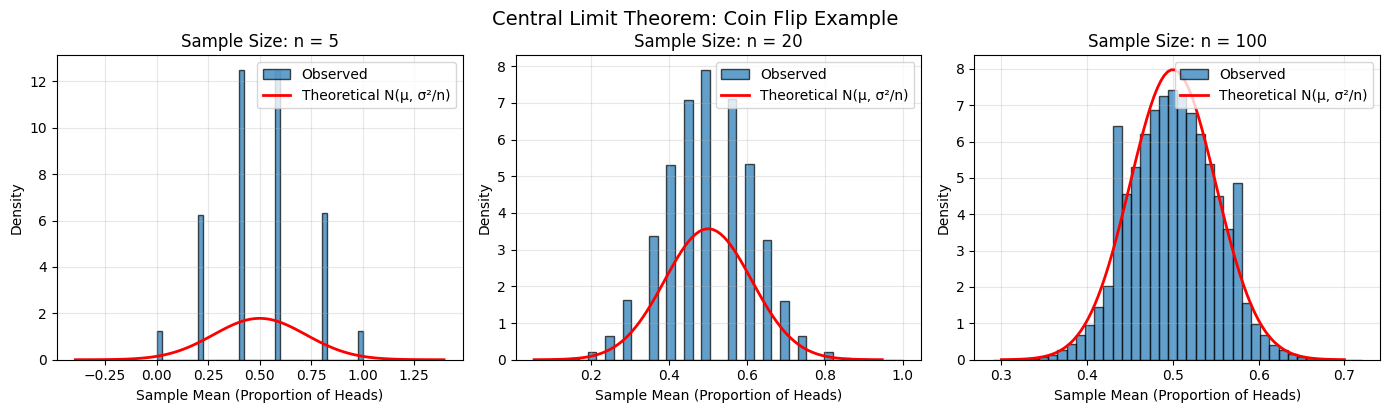

Observation: As sample size increases, the distribution of sample means
becomes increasingly normal, regardless of original distribution (Bernoulli).


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
np.random.seed(42)
# Fair coin
p = 0.5
n_trials = 100000
sample_sizes = [5, 20, 100]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(14, 4))

for idx, n in enumerate(sample_sizes):
    # Generate sample means from multiple experiments
    means = []
    for _ in range(n_trials):
        # Flip coin n times, record fraction of heads
        # 1 = heads, 0 = tails
        flips = np.random.binomial(1, p, n)
        means.append(np.mean(flips))
    
    # Theoretical distribution: N(p, p(1-p)/n)
    mu = p
    sigma = np.sqrt(p * (1 - p) / n)
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    theoretical = stats.norm.pdf(x, mu, sigma)
    
    # Plot
    ax = axes[idx]
    ax.hist(means, bins=40, density=True, alpha=0.7, edgecolor='black', label='Observed')
    ax.plot(x, theoretical, 'r-', linewidth=2, label='Theoretical N(μ, σ²/n)')
    ax.set_xlabel('Sample Mean (Proportion of Heads)')
    ax.set_ylabel('Density')
    ax.set_title(f'Sample Size: n = {n}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Central Limit Theorem: Coin Flip Example', fontsize=14, y=1.02)
plt.show()

print("Observation: As sample size increases, the distribution of sample means")
print("becomes increasingly normal, regardless of original distribution (Bernoulli).")


**Key Observation**: 
- With $n=5$: distribution is somewhat flat (bounded by [0,1])
- With $n=20$: beginning to look normal
- With $n=100$: excellent fit to normal distribution

This occurs even though individual coin flips are Bernoulli (not normal)!

### 2.2 Exponential Distribution Example

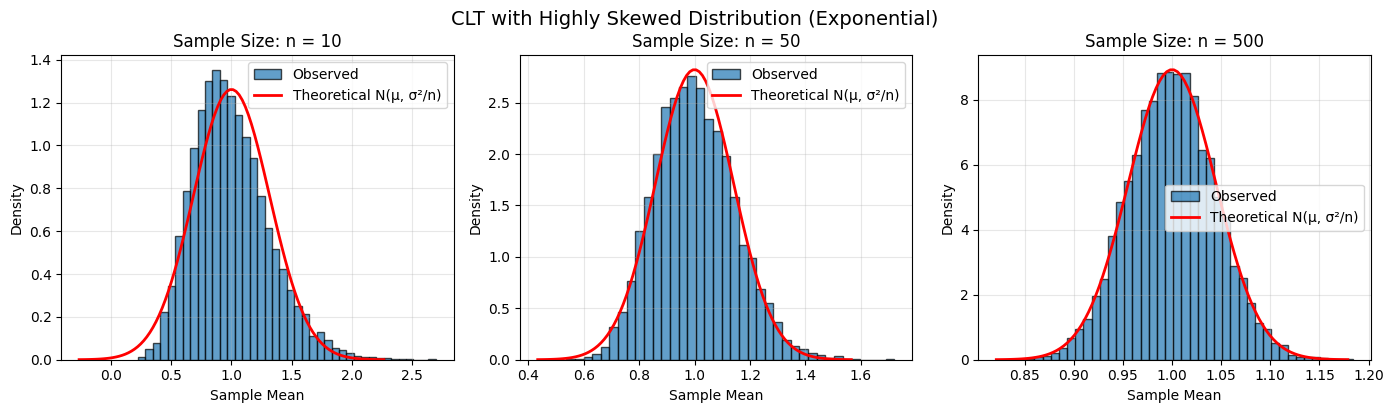

Key Insight: Even starting from a highly skewed exponential distribution,
averaging produces a normal distribution for large enough n.
Note: Convergence is slower for skewed distributions.


In [6]:
# Highly skewed distribution: Exponential
np.random.seed(42)
# Rate parameter
lambda_param = 1.0
n_trials = 10000
sample_sizes = [10, 50, 500]

fig, axes = plt.subplots(1, len(sample_sizes), figsize=(14, 4))

for idx, n in enumerate(sample_sizes):
    # Generate sample means
    means = []
    for _ in range(n_trials):
        samples = np.random.exponential(1/lambda_param, n)
        means.append(np.mean(samples))
    
    # Theoretical: N(1/λ, 1/(λ²n))
    mu = 1 / lambda_param
    sigma = 1 / (lambda_param * np.sqrt(n))
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    theoretical = stats.norm.pdf(x, mu, sigma)
    
    ax = axes[idx]
    ax.hist(means, bins=40, density=True, alpha=0.7, edgecolor='black', label='Observed')
    ax.plot(x, theoretical, 'r-', linewidth=2, label='Theoretical N(μ, σ²/n)')
    ax.set_xlabel('Sample Mean')
    ax.set_ylabel('Density')
    ax.set_title(f'Sample Size: n = {n}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('CLT with Highly Skewed Distribution (Exponential)', fontsize=14, y=1.02)
plt.show()

print("Key Insight: Even starting from a highly skewed exponential distribution,")
print("averaging produces a normal distribution for large enough n.")
print("Note: Convergence is slower for skewed distributions.")


---

## Section 3: Connection to Maximum Likelihood Estimation

### 3.1 Asymptotic Normality of MLE

Recall from the likelihood notebook: for i.i.d. data, the log-likelihood is:
$$\ell(\theta) = \sum_{i=1}^{n} \log p(x_i | \theta)$$

Each term $\log p(x_i | \theta)$ is a random variable (depends on observed data $x_i$).

By the **Law of Large Numbers (LLN)**:
$$\frac{1}{n}\ell(\theta) = \frac{1}{n}\sum_{i=1}^{n} \log p(x_i | \theta) \to \mathbb{E}[\log p(X|\theta)]$$

The MLE $\hat{\theta}_n$ maximizes $\ell(\theta)$, so it maximizes the average log-likelihood.

**Central Limit Theorem applies to the score function** (gradient of log-likelihood):
$$\nabla \ell(\theta^*) = \sum_{i=1}^{n} \nabla \log p(x_i | \theta^*)$$

By CLT, this sum of i.i.d. random variables (gradients) is approximately normal:
$$\nabla \ell(\theta^*) \approx N(0, \mathbf{I}(\theta^*))$$

where $\mathbf{I}(\theta^*)$ is the **Fisher Information Matrix**.

### 3.2 Asymptotic Distribution of MLE

**Result**: For the MLE $\hat{\theta}_n$ under regularity conditions:

$$\sqrt{n}(\hat{\theta}_n - \theta^*) \xrightarrow{d} N\left(0, \mathbf{I}(\theta^*)^{-1}\right)$$

Or equivalently:
$$\hat{\theta}_n \approx N\left(\theta^*, \frac{1}{n}\mathbf{I}(\theta^*)^{-1}\right)$$

**Interpretation**:
- MLE is asymptotically unbiased (centered at true $\theta^*$)
- Variance decreases at rate $1/n$ (collecting more data reduces uncertainty)
- Variance is inversely proportional to Fisher Information (more informative data → lower variance)

### 3.3 Practical Example: Bernoulli MLE

For Bernoulli data with true parameter $p^*$, the MLE is $\hat{p}_n = \frac{k}{n}$ (sample mean).

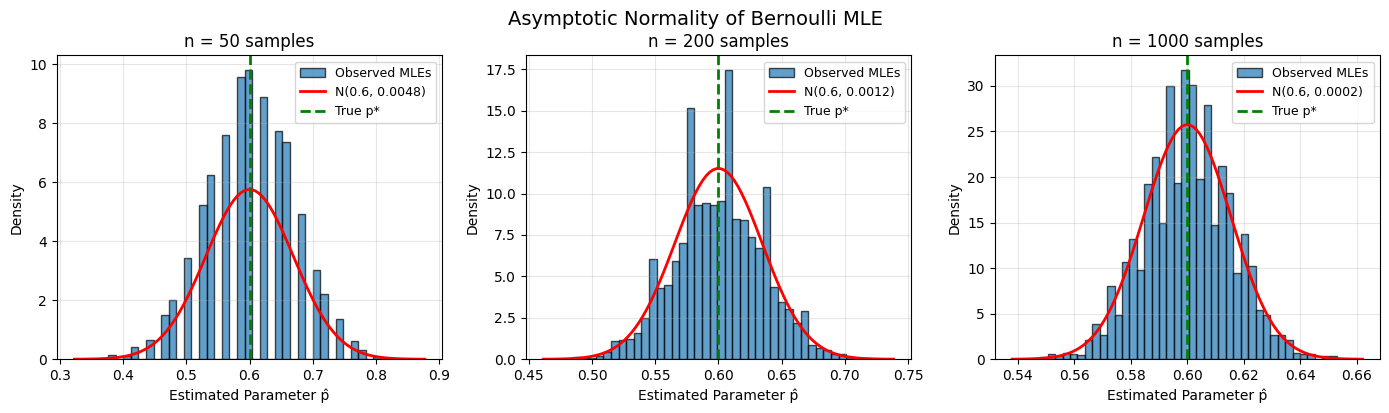

Observation: As n increases, the distribution of MLEs
becomes increasingly concentrated around the true parameter.

Theoretical std dev: σ(n=50) = 0.0693
                     σ(n=200) = 0.0346
                     σ(n=1000) = 0.0155


In [7]:
# Demonstrate asymptotic normality of Bernoulli MLE
np.random.seed(42)
p_true = 0.6
n_samples = [50, 200, 1000]
n_experiments = 5000

fig, axes = plt.subplots(1, len(n_samples), figsize=(14, 4))

for idx, n in enumerate(n_samples):
    # Collect MLE estimates from multiple experiments
    p_estimates = []
    for _ in range(n_experiments):
        data = np.random.binomial(1, p_true, n)
        p_hat = np.mean(data)
        p_estimates.append(p_hat)
    
    # Theoretical distribution
    # Var(p̂) = p(1-p)/n
    sigma_sq = p_true * (1 - p_true) / n
    sigma = np.sqrt(sigma_sq)
    x = np.linspace(p_true - 4*sigma, p_true + 4*sigma, 100)
    theoretical = stats.norm.pdf(x, p_true, sigma)
    
    ax = axes[idx]
    ax.hist(p_estimates, bins=40, density=True, alpha=0.7, edgecolor='black', label='Observed MLEs')
    ax.plot(x, theoretical, 'r-', linewidth=2, label=f'N({p_true}, {sigma_sq:.4f})')
    ax.axvline(p_true, color='green', linestyle='--', linewidth=2, label=f'True p*')
    ax.set_xlabel('Estimated Parameter p̂')
    ax.set_ylabel('Density')
    ax.set_title(f'n = {n} samples')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('Asymptotic Normality of Bernoulli MLE', fontsize=14, y=1.02)
plt.show()

print("Observation: As n increases, the distribution of MLEs")
print("becomes increasingly concentrated around the true parameter.")
print(f"\nTheoretical std dev: σ(n=50) = {np.sqrt(p_true*(1-p_true)/50):.4f}")
print(f"                     σ(n=200) = {np.sqrt(p_true*(1-p_true)/200):.4f}")
print(f"                     σ(n=1000) = {np.sqrt(p_true*(1-p_true)/1000):.4f}")

---

## Section 4: Connection to Stochastic Gradient Descent

### 4.1 Why SGD Works: CLT Perspective

In **Stochastic Gradient Descent**, we update parameters using the gradient from a single (or mini-batch) sample:
$$\theta_{t+1} = \theta_t + \alpha \nabla \log p(x_{i_t} | \theta_t)$$

The instantaneous gradient $\nabla \log p(x_{i_t} | \theta_t)$ is a random variable (depends on which sample we picked).

The **true gradient** we want to follow is:
$$\nabla J(\theta) = \mathbb{E}_{x \sim p(x)}[\nabla \log p(x | \theta)]$$

**CLT perspective**: If we average many independent random gradients:
$$\frac{1}{m}\sum_{i=1}^{m} \nabla \log p(x_i | \theta) \approx N\left(\nabla J(\theta), \frac{\text{Cov}(\nabla \log p(x|\theta))}{m}\right)$$

This is why:
- Mini-batch SGD converges (averaging reduces variance)
- Larger batches are more stable (variance $\propto 1/m$)
- Single-sample SGD is noisy but still converges on average

### 4.2 Convergence Rate Analysis

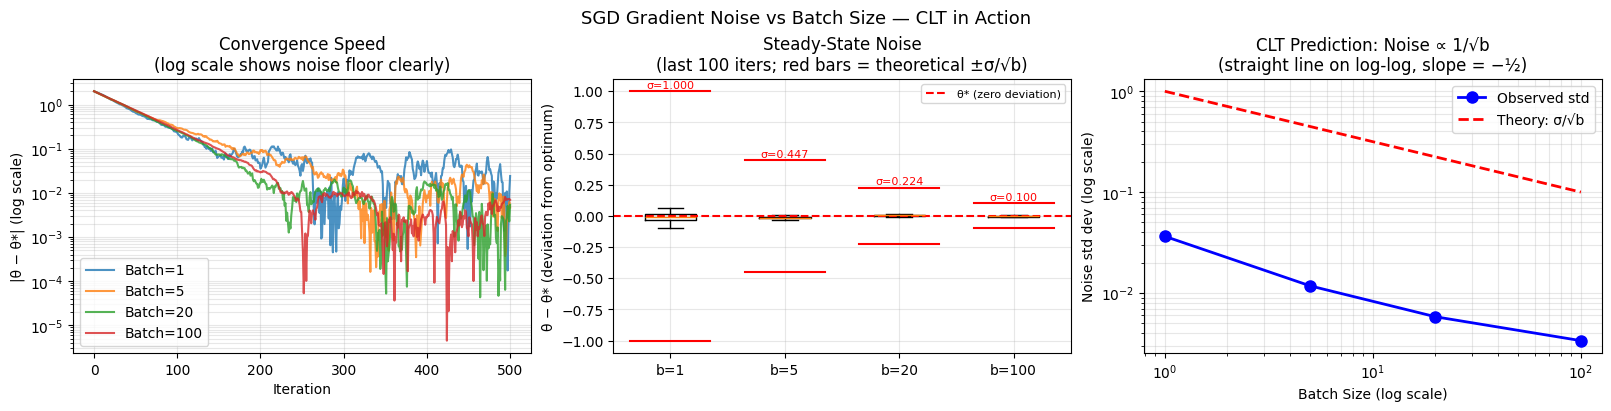

   Batch    Theory σ/√b   Observed std    Ratio
------------------------------------------------
       1         1.0000         0.0364    0.036
       5         0.4472         0.0118    0.026
      20         0.2236         0.0058    0.026
     100         0.1000         0.0034    0.034

Key Insight: Larger batch sizes reduce gradient noise by factor √b (CLT)


: 

In [ ]:
# Demonstrate how gradient noise decreases with batch size
np.random.seed(42)

# Simple quadratic loss: J(θ) = (θ - 2)²
# True gradient: ∇J(θ) = 2(θ - 2)
# Noisy gradient: ∇J(θ) + ε, where ε ~ N(0, σ²_noise)

theta = 0
true_theta_opt = 2
sigma_noise = 1.0
batch_sizes = [1, 5, 20, 100]
n_iterations = 500
alpha = 0.01

results = {}
for batch_size in batch_sizes:
    theta_current = theta
    theta_trajectory = [theta_current]
    for _ in range(n_iterations):
        true_grad = 2 * (theta_current - true_theta_opt)
        noise = np.random.normal(0, sigma_noise, batch_size)
        # Averaging over batch reduces noise by √batch_size (CLT)
        noisy_grad = true_grad + np.mean(noise)
        theta_current = theta_current - alpha * noisy_grad
        theta_trajectory.append(theta_current)
    results[batch_size] = theta_trajectory

# Deviations from optimum in last 100 iterations
final_deviations = {bs: [results[bs][i] - true_theta_opt for i in range(400, 500)] for bs in batch_sizes}
theoretical_std   = {bs: sigma_noise / np.sqrt(bs) for bs in batch_sizes}
observed_std      = {bs: np.std(final_deviations[bs]) for bs in batch_sizes}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)

# --- Panel 1: Distance from optimum on log scale ---
ax = axes[0]
for bs in batch_sizes:
    distance = np.abs(np.array(results[bs]) - true_theta_opt)
    ax.semilogy(distance, label=f'Batch={bs}', alpha=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('|θ − θ*| (log scale)')
ax.set_title('Convergence Speed\n(log scale shows noise floor clearly)')
ax.legend()
ax.grid(alpha=0.3, which='both')

# --- Panel 2: Steady-state deviation centered at 0 ---
ax = axes[1]
ax.boxplot([final_deviations[bs] for bs in batch_sizes],
           tick_labels=[f'b={bs}' for bs in batch_sizes],
           showfliers=False)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5, label='θ* (zero deviation)')
# Horizontal lines at ±theoretical std for each batch size
for i, bs in enumerate(batch_sizes, 1):
    s = theoretical_std[bs]
    ax.plot([i - 0.35, i + 0.35], [ s,  s], 'r-', linewidth=1.5)
    ax.plot([i - 0.35, i + 0.35], [-s, -s], 'r-', linewidth=1.5)
    ax.text(i, s + 0.01, f'σ={s:.3f}', ha='center', va='bottom', fontsize=8, color='red')
ax.set_ylabel('θ − θ* (deviation from optimum)')
ax.set_title('Steady-State Noise\n(last 100 iters; red bars = theoretical ±σ/√b)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Panel 3: Noise scaling — log-log should give slope −½ ---
ax = axes[2]
batch_arr = np.array(batch_sizes, dtype=float)
ax.loglog(batch_arr, [observed_std[bs]   for bs in batch_sizes], 'bo-', label='Observed std', linewidth=2, markersize=8)
ax.loglog(batch_arr, [theoretical_std[bs] for bs in batch_sizes], 'r--', label='Theory: σ/√b',  linewidth=2)
ax.set_xlabel('Batch Size (log scale)')
ax.set_ylabel('Noise std dev (log scale)')
ax.set_title('CLT Prediction: Noise ∝ 1/√b\n(straight line on log-log, slope = −½)')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.suptitle('SGD Gradient Noise vs Batch Size — CLT in Action', fontsize=13)
plt.show()

print(f"{'Batch':>8} {'Theory σ/√b':>14} {'Observed std':>14} {'Ratio':>8}")
print("-" * 48)
for bs in batch_sizes:
    print(f"{bs:>8} {theoretical_std[bs]:>14.4f} {observed_std[bs]:>14.4f} {observed_std[bs]/theoretical_std[bs]:>8.3f}")
print("\nKey Insight: Larger batch sizes reduce gradient noise by factor √b (CLT)")


---

## Section 5: Conditions and Limitations

### 5.1 Lindeberg-Lévy CLT (Most Common)

The **conditions** for CLT to apply are surprisingly weak:

1. **Independence**: $X_1, X_2, \ldots, X_n$ are independent
2. **Identical Distribution**: All have same distribution
3. **Finite Variance**: $\text{Var}(X_i) = \sigma^2 < \infty$

That's it! No requirement that original distribution is normal.

### 5.2 When CLT May Not Apply

CLT can fail if:

| Condition | Issue | Example | Impact on ML |
|-----------|-------|---------|-------------|
| **Non-independent** | Autocorrelation | Time-series data | Need $n$ much larger |
| **Non-identical** | Different distributions | Heteroscedastic data | May not converge |
| **Infinite variance** | Heavy tails | Power-law distributions | CLT doesn't apply |
| **Too few samples** | Pre-asymptotic regime | $n < 30$ with skewed data | Approximation poor |

### 5.3 Rate of Convergence

How large must $n$ be? Depends on **skewness** of original distribution:

- **Symmetric distributions** (uniform, binomial $p=0.5$): $n \geq 20$
- **Mildly skewed** (exponential): $n \geq 100$
- **Highly skewed** (power-law, Pareto): $n \geq 10000$

**Berry-Esseen bound** quantifies convergence rate:
$$\left|P\left(\frac{\bar{X}_n - \mu}{\sigma/\sqrt{n}} \leq x\right) - \Phi(x)\right| \leq \frac{C \cdot \mathbb{E}[|X_1 - \mu|^3]}{\sigma^3 \sqrt{n}}$$

Error decreases as $O(1/\sqrt{n})$, so you need $4\times$ more data for $2\times$ accuracy.

---

## Section 6: Key Takeaways

### 6.1 Central Limit Theorem in One Picture

CLT is the reason that:

1. **Averaging reduces variance** - Take multiple measurements, compute mean → lower uncertainty
2. **Normal distributions are universal** - Many natural phenomena sum many small effects → normal
3. **MLEs are asymptotically normal** - Parameter estimates concentrate around true value
4. **SGD converges** - Individual gradient samples are noisy, but on average point toward optimum
5. **Batch size matters** - Larger batches in SGD have $\sqrt{n}$ times lower noise

### 6.2 Practical Implications for ML

**For data collection:**
- More data → parameter estimates become more precise (at rate $1/\sqrt{n}$)
- Achieving $2\times$ precision requires $4\times$ data

**For optimization:**
- Batch SGD is more stable than single-sample SGD (noise scales as $1/\sqrt{\text{batch size}}$)
- Noise in gradients doesn't prevent convergence, just adds randomness

**For inference:**
- Can construct confidence intervals around MLE estimates
- Can test hypotheses using asymptotic normality
- Uncertainty quantification relies on CLT

### 6.3 Connection to Other Concepts

- **Law of Large Numbers (LLN)**: Sample average → population mean (CLT is the distributional version)
- **Maximum Likelihood Estimation**: MLE is asymptotically normal by CLT
- **Stochastic Gradient Descent**: Averaging multiple noisy updates → follows CLT
- **Confidence Intervals**: Constructed using CLT + normal distribution quantiles
- **Hypothesis Testing**: p-values computed assuming CLT normality

---

## References

1. **Statistical foundations:**
   - Wasserman, L. (2004). *All of Statistics*. Springer. Chapter 5: The Central Limit Theorem
   - Rice, J. A. (2007). *Mathematical Statistics and Data Analysis*. Duxbury. Chapter 6: Large-Sample Theory

2. **CLT and asymptotic inference:**
   - van der Vaart, A. W. (1998). *Asymptotic Statistics*. Cambridge University Press
   - Berry-Esseen theorem: More precise convergence rates

3. **MLE asymptotic properties:**
   - Casella & Berger (2002). *Statistical Inference*. Duxbury. Chapter 10: Asymptotic Evaluations
   - Fisher Information Matrix: Measures amount of information in data

4. **Machine Learning applications:**
   - Bottou, L. (2012). *Stochastic Gradient Descent Tricks*. Neural Networks: Tricks of the Trade
   - Understanding noise in stochastic optimization

5. **Visualization and intuition:**
   - Kruschke, J. K. (2014). *Doing Bayesian Data Analysis*. Academic Press. Chapter 4: Normal Distribution

---
## Practice Exercises

**Conceptual**

1. State the CLT precisely: define all symbols, state the three conditions, and state what convergence "in distribution" means. Why is the condition $\text{Var}(X_i) < \infty$ necessary? Give an example of a distribution that violates this and for which CLT fails.

2. The sample mean $\bar{X}_n$ has $\text{Var}(\bar{X}_n) = \sigma^2/n$. To halve the standard error of estimation, how many more samples do you need? What does this $\sqrt{n}$ scaling imply about the economics of data collection for model training?

3. In mini-batch SGD with batch size $b$, the gradient estimate $\hat{g} = \frac{1}{b}\sum_{i \in \text{batch}} \nabla \ell_i(\theta)$ has variance $\text{Var}(\hat{g}) = \text{Var}(\nabla \ell_i)/b$. By CLT, $\hat{g}$ is approximately Gaussian for large $b$. Explain: (a) why this means the gradient noise decreases as $1/\sqrt{b}$, and (b) why this justifies using larger batches for more stable training.

4. The Berry-Esseen theorem bounds the CLT approximation error as $O(1/\sqrt{n})$. For a Bernoulli($p$) distribution with $p = 0.5$ vs $p = 0.01$, which converges faster to normality? Why? (Hint: consider skewness $\mathbb{E}[|X - \mu|^3]/\sigma^3$.)

5. MLE asymptotic normality states $\sqrt{n}(\hat{\theta}_n - \theta^*) \xrightarrow{d} \mathcal{N}(0, I(\theta^*)^{-1})$ where $I(\theta^*)$ is the Fisher information. What does this say about how uncertainty in $\hat{\theta}$ scales with $n$? Why is high Fisher information desirable?

**Numerical**

6. Verify CLT empirically for three distributions: Bernoulli(0.3), Exponential($\lambda=1$), and Uniform[0, 1]. For each, draw $n \in \{5, 20, 100\}$ samples, compute the standardized mean $Z_n = (\bar{X}_n - \mu)/(\sigma/\sqrt{n})$, repeat 10,000 times, and plot histograms of $Z_n$ alongside the standard normal PDF. Which distribution converges most slowly?

7. Simulate the CLT for MLE: fit Bernoulli MLE $\hat{p}$ to 1,000 datasets of size $n \in \{10, 50, 200\}$ each with true $p = 0.6$. For each $n$, plot the distribution of $\sqrt{n}(\hat{p} - 0.6)$ and overlay $\mathcal{N}(0, p(1-p))$. Verify the CLT prediction.

8. Demonstrate the batch size effect in SGD: for a quadratic loss $J(\theta) = (\theta - 2)^2$ with gradient noise $\sigma = 1$, run 1,000 SGD iterations with batch sizes $b \in \{1, 4, 16, 64\}$. Plot the variance of the iterates in the last 100 steps vs $b$ and verify it scales as $1/b$.

**Reflection**

9. CLT requires independence. In many ML applications — time-series forecasting, language modeling, online learning from streaming data — consecutive samples are correlated. What happens to the CLT's $1/\sqrt{n}$ rate when data is autocorrelated? What is the "effective sample size" and why is it less than $n$ for correlated data?